In [1]:
import yaml
import os
from pathlib import Path
import jax.numpy as jnp
import matplotlib.pyplot as plt
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
config = "config.yml"
config_data = {}
if os.path.exists(config):
    with open(config, 'r') as f:
        config_data = yaml.safe_load(f) or {} 
else:
    print(f"Warning: Config file '{config}' not found. Using defaults.")


In [3]:
trained_models_dir = config_data['deep-ensemble']['trained_models_dir']
real_dataset_path = trained_models_dir.format(seed=0) + "/real_dataset.npy"
real_data = jnp.load(real_dataset_path)
print(f"loaded real data : {real_data.shape}")

loaded real data : (100000, 2)


In [104]:
samples_cache_dir = config_data['sampling']['samples_cache_dir']
# ensemble_samples = jnp.load(Path(samples_cache_dir) / "llla_ensemble_samples.npy")
ensemble_samples = jnp.load(Path(samples_cache_dir) / "deep_ensemble_samples.npy")
print(f"loaded ensemble samples: {ensemble_samples.shape}")
base_samples = ensemble_samples[0]

loaded ensemble samples: (6, 100000, 2)


In [95]:
from generative_uncertainty.compute_uncertainty import get_uncertainty_scores 

In [105]:
uncertainty_scores = get_uncertainty_scores(ensemble_samples)
uncertainty_scores.shape

(100000,)

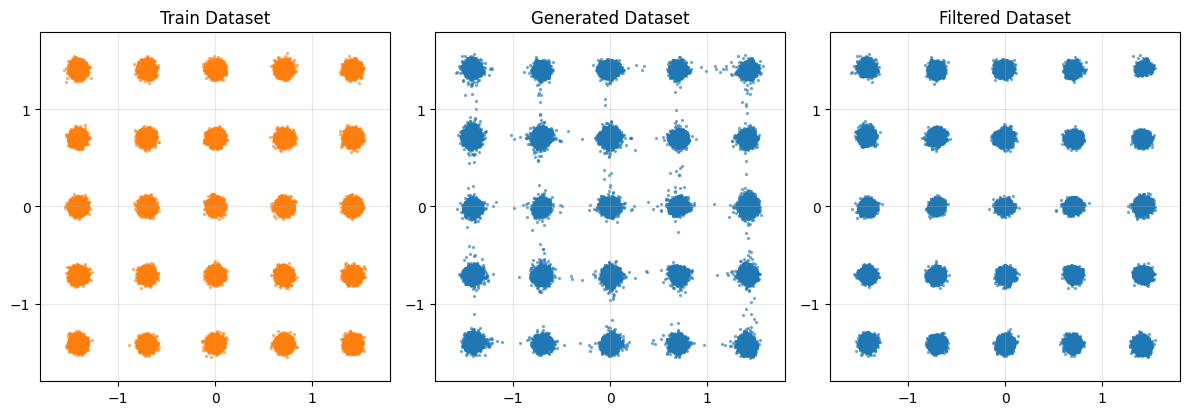

In [113]:
percentile_score = jnp.percentile(uncertainty_scores, 77)
confident_mask = uncertainty_scores <= percentile_score
filtered_samples = base_samples[confident_mask]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter(real_data[:, 0], real_data[:, 1], s=2, alpha=0.5, color='tab:orange')
axes[0].set_title("Train Dataset")

axes[1].scatter(base_samples[:, 0], base_samples[:, 1], s=2, alpha=0.5, color='tab:blue')
axes[1].set_title("Generated Dataset")

axes[2].scatter(filtered_samples[:, 0], filtered_samples[:, 1], s=2, alpha=0.5, color='tab:blue')
axes[2].set_title("Filtered Dataset")

# for i in range(1, num_models):
#     axes[i][1].scatter(ensemble_samples[i, :, 0], ensemble_samples[i, :, 1], s=2, alpha=0.5, color='tab:blue')

for ax in axes:
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    
plt.tight_layout()
# figure_filename = f"./figures/samples_{uncertainty_calc_method}_{percentile_threshold}_{num_samples}_{ensemble_weight_source}.jpg"
# plt.savefig(figure_filename, dpi=300)
# print(f"saved reproduction plot to {figure_filename}")
plt.show()

In [99]:
from generative_uncertainty.scoring import extract_true_gmm_params, evaluate_exact_gmm, score_percentiles
true_means, true_var = extract_true_gmm_params()

In [102]:
df_llla = score_percentiles(real_data, ensemble_samples, uncertainty_scores)

  0%|          | 0/31 [00:00<?, ?it/s]

In [109]:
df_deep = score_percentiles(real_data, ensemble_samples, uncertainty_scores)

  0%|          | 0/31 [00:00<?, ?it/s]

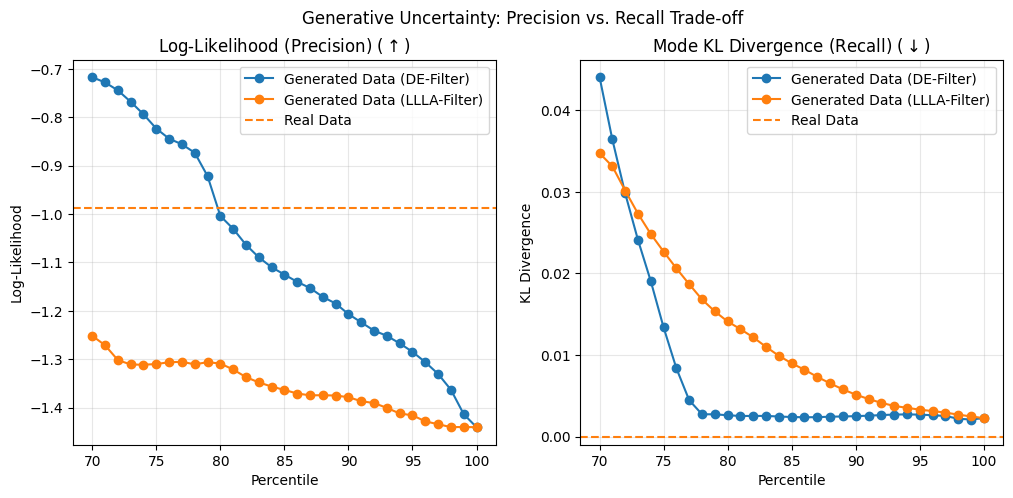

In [111]:
real_data_baseline = evaluate_exact_gmm(real_data, true_means, true_var)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Generative Uncertainty: Precision vs. Recall Trade-off")
axes[0].plot(df_deep.columns, df_deep.loc['avg_log_likelihood'], marker='o', label='Generated Data (DE-Filter)')
axes[1].plot(df_deep.columns, df_deep.loc['mode_kl_divergence'], marker='o', label='Generated Data (DE-Filter)')
axes[0].plot(df_llla.columns, df_llla.loc['avg_log_likelihood'], marker='o', label='Generated Data (LLLA-Filter)')
axes[1].plot(df_llla.columns, df_llla.loc['mode_kl_divergence'], marker='o', label='Generated Data (LLLA-Filter)')
axes[0].axhline(real_data_baseline['avg_log_likelihood'], color='tab:orange', linestyle='--', label='Real Data')
axes[1].axhline(real_data_baseline['mode_kl_divergence'], color='tab:orange', linestyle='--', label='Real Data')
axes[0].set_xlabel('Percentile')
axes[0].set_ylabel('Log-Likelihood')
axes[0].set_title(r'Log-Likelihood (Precision) ($\uparrow$)')
axes[1].set_xlabel('Percentile')
axes[1].set_ylabel('KL Divergence')
axes[1].set_title(r'Mode KL Divergence (Recall) ($\downarrow$)')
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
# axes[1].set_xlim(80, 100)
axes[1].set_ylim(-0.001)
axes[0].legend()
axes[1].legend()